In [320]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Práctica: Estadística Descriptiva (versión sin soluciones)

Este notebook contiene únicamente los **enunciados** de la práctica de Estadística Descriptiva.
Debe completarse por los estudiantes con su propio código y análisis.

Dataset: `descriptive_practice_dataset_large.csv`


## 1) Exploración inicial
- Cargue el dataset y muestre las primeras filas.
- Identifique tipos de variables y valores faltantes.

In [321]:
# Escriba aquí su código
data = pd.read_csv('descriptive_practice_dataset_large.csv')
data.head(10)

,id,gender,age,marital_status,socioeconomic,education,num_children,height_cm,weight_kg,income_usd,commute_min,ticket_price_usd,satisfaction_1_5,owns_car,uses_public_transport,purchase_amount_usd
0,1,Masculino,37.0,Viudo,Medio,Universitario,1,170.6,50.2,8750.76,69,3.70,1.0,No,Si,9.87
1,2,Femenino,19.0,Soltero,Medio,Universitario,0,174.1,55.6,6346.40,1,3.77,2.0,No,No,4.29
2,3,Femenino,40.0,Casado,Alto,Técnico,1,161.0,65.9,3234.99,17,2.76,4.0,No,Si,19.90
3,4,Femenino,42.0,Soltero,Bajo,Universitario,0,170.3,66.1,7348.40,5,5.40,4.0,No,No,27.62
4,5,Masculino,42.0,Casado,Bajo,Universitario,0,159.5,56.8,11370.62,15,4.88,5.0,No,Si,39.12
5,6,Masculino,48.0,Soltero,Alto,Secundaria,0,170.3,65.1,17868.48,14,0.81,4.0,Si,No,23.29
6,7,Masculino,45.0,Soltero,Medio,Universitario,1,168.5,55.4,10733.22,2,0.47,1.0,No,Si,78.01
7,8,Femenino,41.0,Casado,Medio,Posgrado,1,160.6,59.1,10349.56,3,3.45,4.0,Si,No,2.01
8,9,Femenino,34.0,Soltero,Alto,Técnico,1,182.0,60.0,6213.26,15,4.14,2.0,No,No,28.26
9,10,Femenino,16.0,Soltero,Bajo,Secundaria,1,152.6,66.7,3195.89,2,2.23,4.0,Si,No,24.08


# Tipo de cada variable
- id : Nominal
- gender: Nominal
- age: Escalar discreta
- marital_status: Nominal
- socioeconomic: Ordinal
- education: Nominal
- num_children: Escalar discreta
- height_cm: Escalar continua
- weight_kg: Escalar continua
- income_usd: Escalar continua
- commute_min: Escalar continua
- ticket_price_usd: Escalar continua
- satisfaction_1_5: Ordinal
- owns_car: Nominal
- uses_public_transport: Nominal
- purchase_amount_usd: Escalar continua


# Valores faltantes por columna

In [322]:
data.isna().sum()
#data = data.dropna()

id                        0
gender                    0
age                      20
marital_status            0
socioeconomic             0
education                 0
num_children              0
height_cm                20
weight_kg                 0
income_usd               20
commute_min               0
ticket_price_usd          0
satisfaction_1_5         20
owns_car                  0
uses_public_transport     0
purchase_amount_usd       0
dtype: int64

# Estrategia para tratar valores faltantes

- Se pudiera realizar un promedio de la columna con los valores existentes y asignar ese valor en las posiciones faltantes
    - Media o mediana para variables escalares
    - Moda para variables categóricas
- Se pudiera desarrollar un algoritmo de predicción con machine learning para tomar en cuenta todas las demás columnas y predecir que valor es el mas apropiado en cada variable
- Remover filas con valores faltantes para no afectar el análisis de los datos

## 2) Tablas de frecuencia y gráficos
- Genere tablas de frecuencia absoluta y relativa para variables categóricas.
- Dibuje histogramas para variables numéricas seleccionadas.

# Frecuencias absolutas y relativas

In [323]:
# Escriba aquí su código
print("FRECUENCIA ABSOLUTA")
print(data['gender'].value_counts())
print("\nFRECUENCIA RELATIVA EN PORCENTAJE")
print(data['gender'].value_counts(normalize=True) * 100)

FRECUENCIA ABSOLUTA
gender
Femenino     496
Masculino    486
Otro          18
Name: count, dtype: int64

FRECUENCIA RELATIVA EN PORCENTAJE
gender
Femenino     49.6
Masculino    48.6
Otro          1.8
Name: proportion, dtype: float64


In [324]:
# Escriba aquí su código
print("FRECUENCIA ABSOLUTA")
print(data['socioeconomic'].value_counts())
print("\nFRECUENCIA RELATIVA EN PORCENTAJE")
print(data['socioeconomic'].value_counts(normalize=True)*100)

FRECUENCIA ABSOLUTA
socioeconomic
Medio    513
Bajo     357
Alto     130
Name: count, dtype: int64

FRECUENCIA RELATIVA EN PORCENTAJE
socioeconomic
Medio    51.3
Bajo     35.7
Alto     13.0
Name: proportion, dtype: float64


In [325]:
# Escriba aquí su código
print("FRECUENCIA ABSOLUTA")
print(data['education'].value_counts())
print("\nFRECUENCIA RELATIVA EN PORCENTAJE")
print(data['education'].value_counts(normalize=True)*100)

FRECUENCIA ABSOLUTA
education
Universitario    391
Secundaria       253
Técnico          212
Posgrado         101
Primaria          43
Name: count, dtype: int64

FRECUENCIA RELATIVA EN PORCENTAJE
education
Universitario    39.1
Secundaria       25.3
Técnico          21.2
Posgrado         10.1
Primaria          4.3
Name: proportion, dtype: float64


# Histogramas

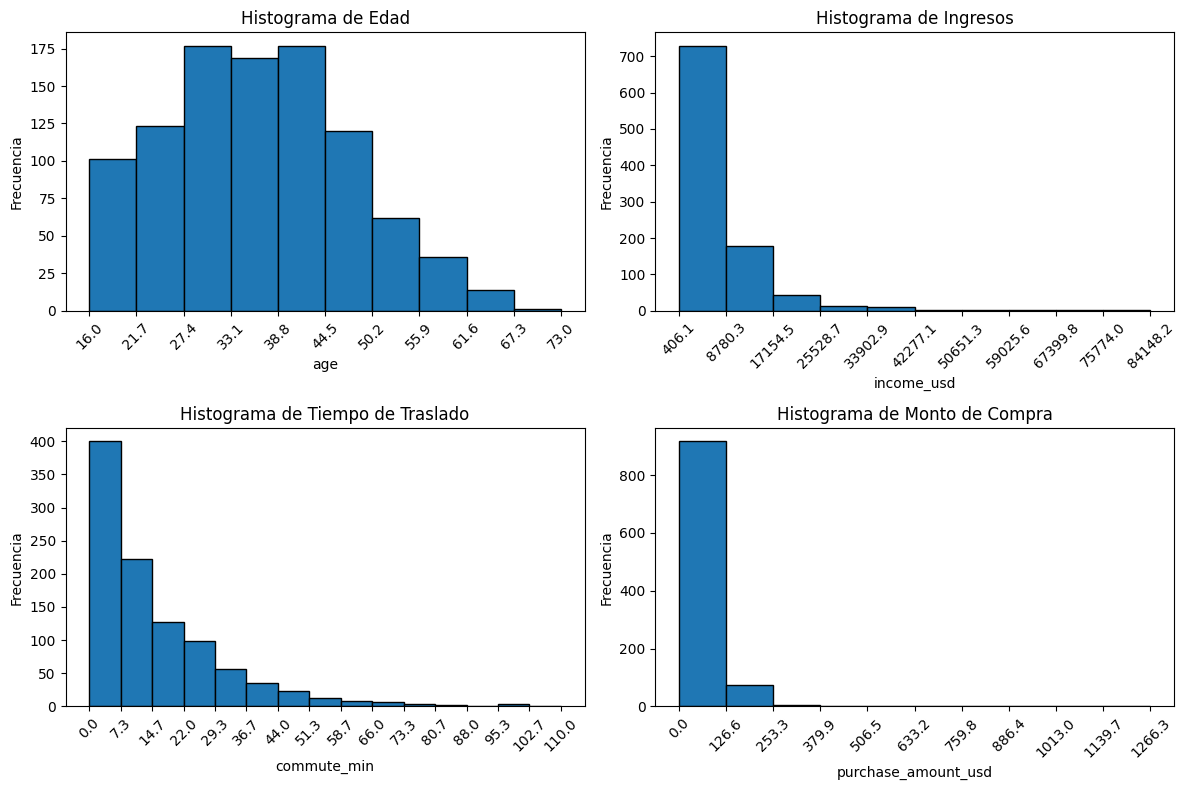

In [326]:
import matplotlib.pyplot as plt
import numpy as np # Added for rounding if needed

variables = [
    ('age', 'Histograma de Edad', 10),
    ('income_usd', 'Histograma de Ingresos', 10),
    ('commute_min', 'Histograma de Tiempo de Traslado', 15),
    ('purchase_amount_usd', 'Histograma de Monto de Compra', 10),
]

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for ax, (column, title, num_bins) in zip(axs.flatten(), variables):
    values = data[column].dropna()
    counts, bin_edges, patches = ax.hist(values, bins=num_bins, edgecolor='black')
    ax.set_xticks(bin_edges)
    tick_labels = [f"{val:.1f}" for val in bin_edges]
    ax.set_xticklabels(tick_labels, rotation=45)
    
    # Set titles and labels
    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Tabla de frecuencia agrupada

In [345]:
#tabla de frecuencia agrupada de income
print("FRECUENCIA AGRUPADA")
print(data['income_usd'].value_counts(bins=10))


FRECUENCIA AGRUPADA
(322.387, 8780.333]       729
(8780.333, 17154.536]     177
(17154.536, 25528.739]     44
(25528.739, 33902.942]     13
(33902.942, 42277.145]     11
(42277.145, 50651.348]      2
(50651.348, 59025.551]      1
(59025.551, 67399.754]      1
(67399.754, 75773.957]      1
(75773.957, 84148.16]       1
Name: count, dtype: int64


## 3) Medidas de tendencia central
- Calcule media, mediana, moda e interprete resultados.

In [344]:
variables = ['age', 'income_usd', 'commute_min', 'purchase_amount_usd']

for var in variables:
    print('-' * 40)
    print(f"Media de {var}: {data[var].mean()}")
    print(f"Mediana de {var}: {data[var].median()}")
    print(f"Moda de {var}: {data[var].mode()[0]}")


----------------------------------------
Media de age: 36.39387755102041
Mediana de age: 36.0
Moda de age: 16.0
----------------------------------------
Media de income_usd: 7318.094989795918
Mediana de income_usd: 5124.915
Moda de income_usd: 406.13
----------------------------------------
Media de commute_min: 15.313
Mediana de commute_min: 10.0
Moda de commute_min: 2
----------------------------------------
Media de purchase_amount_usd: 54.16267
Mediana de purchase_amount_usd: 37.535
Moda de purchase_amount_usd: 3.21


# Interpretación de income_usd

La presencia de asimetria indica que existen valores mucho mas grandes que la mediana que afectan a la media de la variable lo que podria significar valores outliers o gastos que requieren nuestra atención por ser sumamente mas elevados que lo normal.

## 4) Medidas de dispersión
- Calcule rango, varianza, desviación estándar, coeficiente de variación.
- Identifique y analice outliers con IQR.

In [329]:
# Escriba aquí su código

## 5) Medidas de posición
- Calcule percentiles y cuartiles y explique su significado.

In [330]:
# Escriba aquí su código

## 6) Boxplots
- Cree boxplots para comparar distribuciones entre grupos.

In [331]:
# Escriba aquí su código

## 7) Tablas de contingencia
- Construya tablas de contingencia y realice prueba chi-cuadrado.

In [332]:
# Escriba aquí su código

## 8) Correlación y análisis bivariado
- Calcule la matriz de correlación y realice gráficos de dispersión.

In [333]:
# Escriba aquí su código

## 9) Informe final
- Redacte una página de conclusiones e interpretación de hallazgos.

In [334]:
# Escriba aquí su código